In [ ]:
!pip install idna==3.7

In [ ]:
!pip install -q roboflow tensorflow scikit-learn matplotlib seaborn pandas

In [ ]:
import os
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

tf.random.set_seed(SEED)
np.random.seed(SEED)

os.makedirs("assets/eda", exist_ok=True)
os.makedirs("assets/model_results", exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("docs", exist_ok=True)

In [ ]:
from roboflow import Roboflow

rf = Roboflow(api_key="WkL4OtuLgshp3030KOkW")

project = rf.workspace("saumya-roboflow").project("brain-tumour-u5c2b")
version = project.version(1)

dataset = version.download("folder")

DATASET_DIR = dataset.location
print("Dataset indirildiği yer:", DATASET_DIR)

loading Roboflow workspace...
loading Roboflow project...
Dataset indirildiği yer: /content/Brain-Tumour-1


In [ ]:
print("Ana dataset klasörü:", DATASET_DIR)
print("İçindeki dosya/klasörler:")

for item in os.listdir(DATASET_DIR):
    print("-", item)

Ana dataset klasörü: /content/Brain-Tumour-1
İçindeki dosya/klasörler:
- README.dataset.txt
- train
- test
- README.roboflow.txt


In [ ]:
train_dir = os.path.join(DATASET_DIR, "train")
test_dir = os.path.join(DATASET_DIR, "test")

print("Train var mı?", os.path.exists(train_dir))
print("Test var mı?", os.path.exists(test_dir))

Train var mı? True
Test var mı? True


In [ ]:
print("Train klasöründeki sınıflar:")
for item in os.listdir(train_dir):
    print("-", item)

print("\nTest klasöründeki sınıflar:")
for item in os.listdir(test_dir):
    print("-", item)

Train klasöründeki sınıflar:
- pituitary
- glioma
- meningioma
- no

Test klasöründeki sınıflar:
- pituitary
- glioma
- meningioma
- no


In [ ]:
import pathlib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def count_images_per_class(folder_path):
    folder = pathlib.Path(folder_path)
    counts = {}

    image_extensions = ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp"]

    for class_folder in folder.iterdir():
        if class_folder.is_dir():
            count = 0
            for ext in image_extensions:
                count += len(list(class_folder.glob(ext)))
            counts[class_folder.name] = count

    return counts

In [ ]:
train_counts = count_images_per_class(train_dir)
test_counts = count_images_per_class(test_dir)

print("Train:", train_counts)
print("Test:", test_counts)

Train: {'pituitary': 1428, 'glioma': 1932, 'meningioma': 1230, 'no': 1325}
Test: {'pituitary': 336, 'glioma': 380, 'meningioma': 301, 'no': 381}


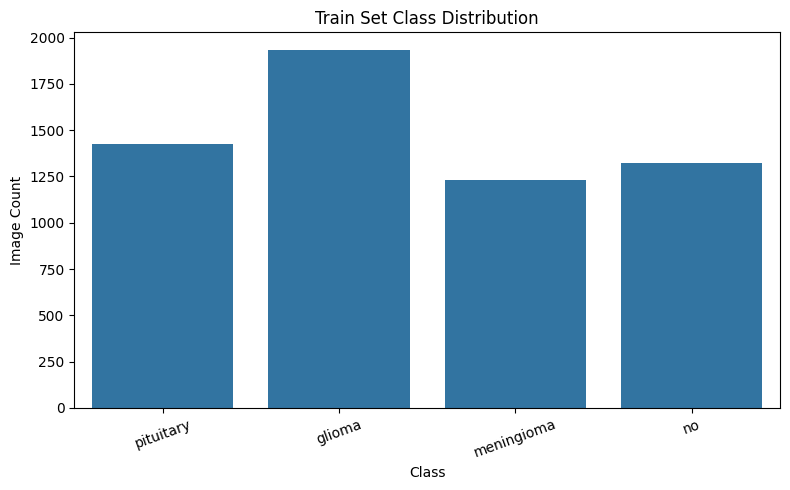

In [ ]:
class_df = pd.DataFrame({
    "class_name": list(train_counts.keys()),
    "image_count": list(train_counts.values())
})

plt.figure(figsize=(8, 5))
sns.barplot(data=class_df, x="class_name", y="image_count")
plt.title("Train Set Class Distribution")
plt.xlabel("Class")
plt.ylabel("Image Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("assets/eda/class_distribution.png", dpi=150)
plt.show()

In [ ]:
import tensorflow as tf
import numpy as np
import os

SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

Found 5915 files belonging to 4 classes.
Using 4732 files for training.
Found 5915 files belonging to 4 classes.
Using 1183 files for validation.


In [ ]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

Found 1398 files belonging to 4 classes.


In [ ]:
class_names = train_ds.class_names
num_classes = len(class_names)

print("Sınıflar:", class_names)
print("Sınıf sayısı:", num_classes)

Sınıflar: ['glioma', 'meningioma', 'no', 'pituitary']
Sınıf sayısı: 4


In [ ]:
display_class_names = {
    "glioma": "glioma",
    "meningioma": "meningioma",
    "no": "no_tumor",
    "pituitary": "pituitary"
}

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
valid_ds = valid_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [ ]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
], name="data_augmentation")

In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
inputs = tf.keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

checkpoint = ModelCheckpoint(
    filepath="models/baseline_mobilenetv2.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True
)

In [ ]:
EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.5886 - loss: 1.0139
Epoch 1: val_accuracy improved from None to 0.84615, saving model to models/baseline_mobilenetv2.keras

Epoch 1: finished saving model to models/baseline_mobilenetv2.keras
148/148 ━━━━━━━━━━━━━━━━━━━━ 23s 91ms/step - accuracy: 0.7272 - loss: 0.6904 - val_accuracy: 0.8462 - val_loss: 0.4437
Epoch 2/10
147/148 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8387 - loss: 0.4434
Epoch 2: val_accuracy improved from 0.84615 to 0.85376, saving model to models/baseline_mobilenetv2.keras

Epoch 2: finished saving model to models/baseline_mobilenetv2.keras
148/148 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - accuracy: 0.8529 - loss: 0.4026 - val_accuracy: 0.8538 - val_loss: 0.3803
Epoch 3/10
147/148 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.8693 - loss: 0.3700
Epoch 3: val_accuracy did not improve from 0.85376
148/148 ━━━━━━━━━━━━━━━━━━━━ 10s 70ms/step - accuracy: 0.8781 - loss: 0.3425 - val_accuracy: 0.8462 - v

In [ ]:
history_df = pd.DataFrame(history.history)
history_df

,accuracy,loss,val_accuracy,val_loss
0,0.727177,0.690389,0.846154,0.443678
1,0.852916,0.402558,0.853762,0.380294
2,0.878064,0.342454,0.846154,0.387465
3,0.877853,0.318129,0.861369,0.351340
4,0.890533,0.293253,0.880812,0.333721
5,0.892857,0.290125,0.859679,0.367124
6,0.890533,0.281854,0.868132,0.342750
7,0.902790,0.260850,0.883347,0.326395
8,0.894336,0.274091,0.869823,0.350599
9,0.896027,0.269911,0.880812,0.327575


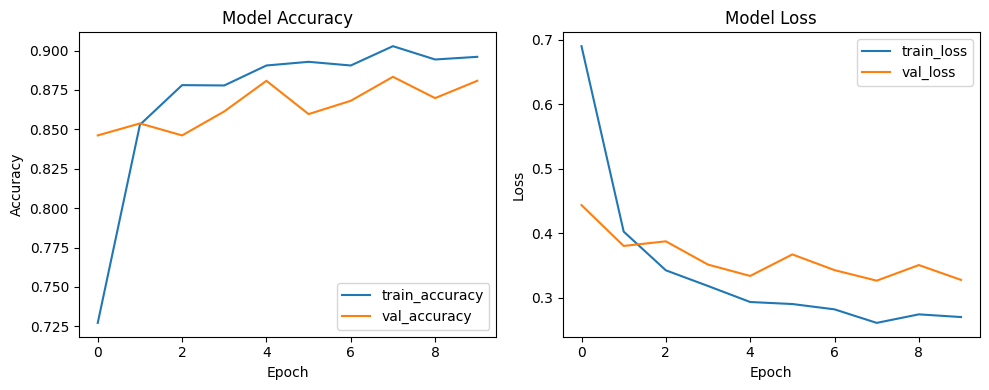

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history_df["accuracy"], label="train_accuracy")
plt.plot(history_df["val_accuracy"], label="val_accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_df["loss"], label="train_loss")
plt.plot(history_df["val_loss"], label="val_loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.savefig("assets/model_results/training_curves.png", dpi=150)
plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.7911 - loss: 0.6683
Test Loss: 0.6682628989219666
Test Accuracy: 0.7911301851272583


In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [ ]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

      glioma       0.88      0.71      0.79       380
  meningioma       0.73      0.50      0.60       301
          no       0.85      0.93      0.89       381
   pituitary       0.70      0.98      0.82       336

    accuracy                           0.79      1398
   macro avg       0.79      0.78      0.77      1398
weighted avg       0.80      0.79      0.78      1398



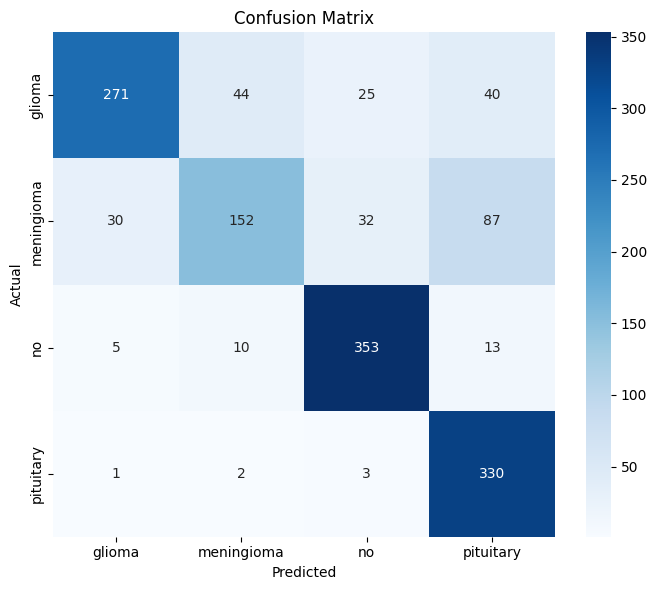

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("assets/model_results/confusion_matrix.png", dpi=150)
plt.show()

In [ ]:
def predict_image(image_path):
    img = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array, verbose=0)[0]

    predicted_index = np.argmax(predictions)
    predicted_class = class_names[predicted_index]
    confidence = predictions[predicted_index]

    display_name = display_class_names.get(predicted_class, predicted_class)

    print("Tahmin:", display_name)
    print("Güven skoru:", round(float(confidence), 4))

    plt.imshow(img)
    plt.title(f"Tahmin: {display_name} | Güven: {confidence:.2f}")
    plt.axis("off")
    plt.show()

Tahmin: glioma
Güven skoru: 0.9605


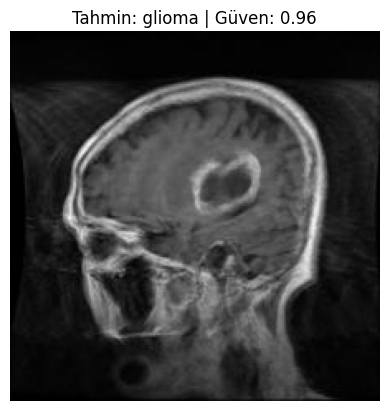

In [ ]:
sample_class_folder = pathlib.Path(test_dir) / class_names[0]
sample_image_path = list(sample_class_folder.glob("*"))[0]

predict_image(sample_image_path)

In [ ]:
model.save("models/baseline_mobilenetv2.keras")
print("Model kaydedildi.")

Model kaydedildi.


In [ ]:
dataset_report = f"""
# Dataset Bilgisi

Bu projede Roboflow Universe üzerinde yayınlanan Brain Tumour Classification dataset'i kullanılmıştır.

## Görev Tipi
Image Classification

## Sınıflar
{chr(10).join([f"- {display_class_names.get(c, c)}" for c in class_names])}

## Görüntü Boyutu
Model eğitiminde görüntüler {IMG_SIZE[0]}x{IMG_SIZE[1]} boyutuna getirilmiştir.

## Kullanım Amacı
MR görüntüsünden beyin tümörü sınıfını tahmin eden bir derin öğrenme modeli geliştirmek.

## Not
Dataset dosyaları GitHub reposuna yüklenmemiştir. Veri seti Roboflow üzerinden indirilmiş ve lokal/Colab ortamında kullanılmıştır.
"""

with open("docs/dataset.md", "w", encoding="utf-8") as f:
    f.write(dataset_report)

print(dataset_report)


# Dataset Bilgisi

Bu projede Roboflow Universe üzerinde yayınlanan Brain Tumour Classification dataset'i kullanılmıştır.

## Görev Tipi
Image Classification

## Sınıflar
- glioma
- meningioma
- no_tumor
- pituitary

## Görüntü Boyutu
Model eğitiminde görüntüler 224x224 boyutuna getirilmiştir.

## Kullanım Amacı
MR görüntüsünden beyin tümörü sınıfını tahmin eden bir derin öğrenme modeli geliştirmek.

## Not
Dataset dosyaları GitHub reposuna yüklenmemiştir. Veri seti Roboflow üzerinden indirilmiş ve lokal/Colab ortamında kullanılmıştır.



In [ ]:
model_report = f"""
# Sprint 1 Model Raporu

## Model
MobileNetV2 tabanlı transfer learning modeli kullanılmıştır.

## Amaç
İlk sprintte amaç yüksek doğruluk elde etmekten çok çalışan bir baseline model ve uçtan uca veri hattı oluşturmaktır.

## Sınıflar
{chr(10).join([f"- {display_class_names.get(c, c)}" for c in class_names])}

## Eğitim Ayarları
- Image size: {IMG_SIZE[0]}x{IMG_SIZE[1]}
- Batch size: {BATCH_SIZE}
- Epoch: {EPOCHS}
- Optimizer: Adam
- Loss: Categorical Crossentropy
- Model: MobileNetV2 + GlobalAveragePooling + Dropout + Dense

## Test Sonucu
- Test Loss: {test_loss:.4f}
- Test Accuracy: {test_accuracy:.4f}

## Çıktılar
- assets/eda/class_distribution.png
- assets/eda/sample_images.png
- assets/model_results/training_curves.png
- assets/model_results/confusion_matrix.png

## Sprint 2 Planı
- EfficientNetB0 veya DenseNet modeli denenecek.
- Fine-tuning yapılacak.
- Grad-CAM ile modelin görüntüde hangi bölgeye odaklandığı gösterilecek.
- Model Taha'nın geliştireceği arayüze bağlanacak.

## Medikal Uyarı
Bu proje klinik tanı koymak amacıyla değil, eğitim ve karar destek prototipi amacıyla geliştirilmiştir.
"""

with open("docs/model_report.md", "w", encoding="utf-8") as f:
    f.write(model_report)

print(model_report)


# Sprint 1 Model Raporu

## Model
MobileNetV2 tabanlı transfer learning modeli kullanılmıştır.

## Amaç
İlk sprintte amaç yüksek doğruluk elde etmekten çok çalışan bir baseline model ve uçtan uca veri hattı oluşturmaktır.

## Sınıflar
- glioma
- meningioma
- no_tumor
- pituitary

## Eğitim Ayarları
- Image size: 224x224
- Batch size: 32
- Epoch: 10
- Optimizer: Adam
- Loss: Categorical Crossentropy
- Model: MobileNetV2 + GlobalAveragePooling + Dropout + Dense

## Test Sonucu
- Test Loss: 0.6683
- Test Accuracy: 0.7911

## Çıktılar
- assets/eda/class_distribution.png
- assets/eda/sample_images.png
- assets/model_results/training_curves.png
- assets/model_results/confusion_matrix.png

## Sprint 2 Planı
- EfficientNetB0 veya DenseNet modeli denenecek.
- Fine-tuning yapılacak.
- Grad-CAM ile modelin görüntüde hangi bölgeye odaklandığı gösterilecek.
- Model Taha'nın geliştireceği arayüze bağlanacak.

## Medikal Uyarı
Bu proje klinik tanı koymak amacıyla değil, eğitim ve karar destek protot